In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\dataset\train_set_acute_cardiotoxicity_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

[18:16:05] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored
[18:16:06] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored
[18:16:09] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored


Train DataFrame:
                                              smiles labels  \
0  N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...      0   
1  CO[C@@H](C)CN(CCc1ccc(Cl)cc1)C1CCN(c2nc(N)n[nH...      0   
2  CC(C)(C)NC(=O)n1nc(NCC(=O)NC2CN([C@H]3CC[C@@H]...      1   
3  Cc1ccc2c(-c3nnc(SCCCN4CCc5cc6nc(C(F)(F)F)oc6cc...      1   
4  CC(C)[C@H](N)C(=O)N1CC(c2cc(F)ccc2F)=C[C@H]1c1...      1   

                                          IUPAC name ID  \
0  6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...      
1  1-(5-amino-1H-1,2,4-triazol-3-yl)-N-[2-(4-chlo...      
2  3-[[2-[[1-[4-(1,3-benzodioxol-5-yl)cyclohexyl]...      
3  7-[3-[[4-methyl-5-(2-methylquinolin-5-yl)-1,2,...      
4  (2S)-2-amino-1-[(2S)-4-(2,5-difluorophenyl)-2-...      

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ...   
3  [0, 0, 0, 0, 0, 0, 0, 

In [3]:
#renaming column
train_df = train_df.rename(columns={'labels': 'Outcome'})

#showing column 
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df['RowID'] = train_df.index
train_df.head(100)

,smiles,Outcome,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,RowID
0,N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,0,"6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5425815895003938, 1.751943692500183, 1.5141...",N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,0
4479,CC(C)C(Cn1ccnc1)NC(=O)NC1CCN(Cc2ccn(-c3ccc(C(F...,0,1-(1-imidazol-1-yl-3-methylbutan-2-yl)-3-[1-[[...,,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8217267374698773, 0.5839157687155, 0.743269...",CC(C)C(Cn1ccnc1)NC(=O)NC1CCN(Cc2ccn(-c3ccc(C(F...,4479
4478,Cc1ccc(OC(=O)N(CC(=O)O)Cc2cccc(OCc3nc(-c4ccc(C...,0,"2-[[3-[[2-(4-chlorophenyl)-5-methyl-1,3-oxazol...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9467144649001344, 1.106034233791901, 0.7147...",Cc1ccc(OC(=O)N(CC(=O)O)Cc2cccc(OCc3nc(-c4ccc(C...,4478
4477,CO[C@H]1CC[C@H](N2C(=O)CNc3ncc(-c4ccc(C(C)(C)O...,0,3-[6-(2-hydroxypropan-2-yl)pyridin-3-yl]-5-(4-...,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.26756503893179207, -0.10791615537235065, -...",CO[C@H]1CC[C@H](N2C(=O)CNc3ncc(-c4ccc(C(C)(C)O...,4477
4475,CN1CC[C@H](N(C)C(=O)N2CC(c3cc(F)ccc3F)=C[C@@]2...,0,"(5S)-3-(2,5-difluorophenyl)-N-[(3S,4S)-3-fluor...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6455177736401956, 0.30538603304376793, 0.30...",CN1CC[C@H](N(C)C(=O)N2CC(c3cc(F)ccc3F)=C[C@@]2...,4475
...,...,...,...,...,...,...,...,...,...
4659,NC[C@]1(c2cccc(Cl)c2)CC[C@H](N2CCn3c(nnc3C(F)(...,0,7-[4-(aminomethyl)-4-(3-chlorophenyl)cyclohexy...,,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.33799258985214276, 0.15364223439823624, 0.6...",NC[C@]1(c2cccc(Cl)c2)CC[C@H](N2CCn3c(nnc3C(F)(...,4659
4660,Cc1onc(-c2ccccc2Cl)c1C(=O)N(C)c1ccc(Cl)cc1,0,"3-(2-chlorophenyl)-N-(4-chlorophenyl)-N,5-dime...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8826154065078982, -0.6450093374203502, -0....",Cc1onc(-c2ccccc2Cl)c1C(=O)N(C)c1ccc(Cl)cc1,4660
4692,CCc1cc2c(cc1N1CCN(CC3(O)CCOCC3)CC1)C(C)(C)c1[n...,0,9-ethyl-8-[4-[(4-hydroxyoxan-4-yl)methyl]piper...,,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.3892138262515674, 0.8175213534724366, 0.700...",CCc1cc2c(cc1N1CCN(CC3(O)CCOCC3)CC1)C(C)(C)c1[n...,4692
4689,COc1nn(-c2cnccn2)cc1C(=O)Nc1cccc(-c2nncn2C(C)C)n1,0,"3-methoxy-N-[6-(4-propan-2-yl-1,2,4-triazol-3-...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.3892138262515674, 0.7905668629235594, 0.561...",COc1nn(-c2cnccn2)cc1C(=O)Nc1cccc(-c2nncn2C(C)C)n1,4689


Classes                          :  ['0' '1']
Number of cpds in each class     :  [3568 4703]
Total number of cpds             :  8271


{'0': 0, '1': 1}

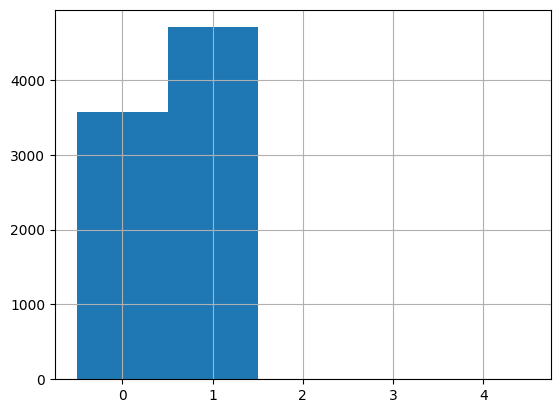

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [5]:
y= np.int32((S))
x = np.array(list(train_df['MACCS_Descriptors']))

In [6]:
print(x)

[[0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]
 ...
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]]


In [7]:
# Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12, x.shape[1] // 10,
        x.shape[1] // 7, x.shape[1] // 5, x.shape[1] // 3
    ],
    "n_estimators": [10, 100, 300],
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_rf_maccs = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced'),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

model_rf_maccs.fit(x, y)

best_model_rf_maccs = model_rf_maccs.best_estimator_

print("Best Params:", model_rf_maccs.best_params_)
print("Best Score :", model_rf_maccs.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'max_features': 16, 'n_estimators': 300}
Best Score : 0.5578144515025787


In [8]:
# Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    best_model_rf_maccs.fit(X_train, y_train)
    
    y_pred = best_model_rf_maccs.predict(X_test)
    y_proba = best_model_rf_maccs.predict_proba(X_test)[:, 1]  
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[499 215]
 [171 770]]
Confusion Matrix for Fold 2:
[[510 204]
 [178 762]]
Confusion Matrix for Fold 3:
[[522 192]
 [158 782]]
Confusion Matrix for Fold 4:
[[517 196]
 [164 777]]
Confusion Matrix for Fold 5:
[[500 213]
 [169 772]]
Overall CV Accuracy: 0.7751188914907374
Overall CV AUC: 0.8520130301004624
Overall CV Precision: 0.7911476007369123
Overall CV Recall (Sensitivity): 0.8213905532819318
Overall CV F1 Score: 0.8059750981098801
Overall CV Specificity: 0.7141250329023615
Overall CV PPV (Positive Predictive Value): 0.7911476007369123
Overall CV NPV (Negative Predictive Value): 0.7520528166664773
Overall CV CCR (Correct Classification Rate): 0.7677577930921468


In [17]:
# SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "C": [0.1, 1, 10, 15],
    "kernel": ['rbf'],
    "gamma": ['scale', 'auto']
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_svm_maccs = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

model_svm_maccs.fit(x, y)
best_model_svm_maccs = model_svm_maccs.best_estimator_

print("Best Params:", model_svm_maccs.best_params_)
print("Best Score :", model_svm_maccs.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 15, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.5412587868498194


In [18]:
# SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    best_model_svm_maccs.fit(X_train, y_train)
    
    y_pred = best_model_svm_maccs.predict(X_test)
    y_proba = best_model_svm_maccs.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[500 214]
 [174 767]]
Confusion Matrix for Fold 2:
[[511 203]
 [190 750]]
Confusion Matrix for Fold 3:
[[525 189]
 [171 769]]
Confusion Matrix for Fold 4:
[[534 179]
 [180 761]]
Confusion Matrix for Fold 5:
[[518 195]
 [182 759]]
Overall CV Accuracy: 0.7730634148836292
Overall CV AUC: 0.8416526122648822
Overall CV Precision: 0.7953459294167042
Overall CV Recall (Sensitivity): 0.8092701291066543
Overall CV F1 Score: 0.8022092237897291
Overall CV Specificity: 0.7253432649357079
Overall CV PPV (Positive Predictive Value): 0.7953459294167042
Overall CV NPV (Negative Predictive Value): 0.7426015795261091
Overall CV CCR (Correct Classification Rate): 0.767306697021181


In [11]:
# XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [3, 5, 7],
    "n_estimators": [100, 200],
    "learning_rate": [0.1, 0.2, 0.4]
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_xgb_maccs = GridSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss'),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

model_xgb_maccs.fit(x, y)
best_model_xgb_maccs = model_xgb_maccs.best_estimator_

print("Best Params:", model_xgb_maccs.best_params_)
print("Best Score :", model_xgb_maccs.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Params: {'learning_rate': 0.4, 'max_depth': 7, 'n_estimators': 100}
Best Score : 0.5451454313398477


In [12]:
# XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    best_model_xgb_maccs.fit(X_train, y_train)
    
    y_pred = best_model_xgb_maccs.predict(X_test)
    y_proba = best_model_xgb_maccs.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[510 204]
 [169 772]]
Confusion Matrix for Fold 2:
[[501 213]
 [186 754]]
Confusion Matrix for Fold 3:
[[515 199]
 [177 763]]
Confusion Matrix for Fold 4:
[[517 196]
 [180 761]]
Confusion Matrix for Fold 5:
[[506 207]
 [176 765]]
Overall CV Accuracy: 0.7694347494127575
Overall CV AUC: 0.8457974876337966
Overall CV Precision: 0.7892168752731834
Overall CV Recall (Sensitivity): 0.8111825355552039
Overall CV F1 Score: 0.8000393959634909
Overall CV Specificity: 0.7144075021312872
Overall CV PPV (Positive Predictive Value): 0.7892168752731834
Overall CV NPV (Negative Predictive Value): 0.7416535406378337
Overall CV CCR (Correct Classification Rate): 0.7627950188432455


In [13]:
# NN
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
import pandas as pd
import numpy as np

# preparing data 
if 'x' not in locals():
    raise ValueError("Variabel 'x' dan 'y' belum didefinisikan!")

if isinstance(x, (pd.DataFrame, pd.Series)):
    X_data = x.to_numpy()
else:
    X_data = x

if isinstance(y, (pd.DataFrame, pd.Series)):
    y_data = y.to_numpy()
else:
    y_data = y

# parameter tuning
paramgrid_nn = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50)], 
    'activation': ['relu'],           
    'alpha': [0.0001, 0.01],          
    'learning_rate_init': [0.001, 0.01] 
}

cv_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_maccs = GridSearchCV(
    estimator=MLPClassifier(
        solver='adam',          
        max_iter=1000,          
        early_stopping=True,    
        random_state=24
    ),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv_split,
    verbose=1,
    n_jobs=-1 
)

model_nn_maccs.fit(X_data, y_data)
best_model_nn_maccs = model_nn_maccs.best_estimator_

print("Best Params:", model_nn_maccs.best_params_)
print("Best Score :", model_nn_maccs.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Best Score : 0.5063079488384278


In [14]:
# NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    best_model_nn_maccs.fit(X_train, y_train)
    
    y_pred = best_model_nn_maccs.predict(X_test)
    y_proba = best_model_nn_maccs.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[488 226]
 [212 729]]
Confusion Matrix for Fold 2:
[[430 284]
 [141 799]]
Confusion Matrix for Fold 3:
[[522 192]
 [205 735]]
Confusion Matrix for Fold 4:
[[544 169]
 [255 686]]
Confusion Matrix for Fold 5:
[[487 226]
 [205 736]]
Overall CV Accuracy: 0.7442883497663817
Overall CV AUC: 0.8215601229172247
Overall CV Precision: 0.7722816913793256
Overall CV Recall (Sensitivity): 0.7835561987021503
Overall CV F1 Score: 0.7767396063862624
Overall CV Specificity: 0.6925619055476328
Overall CV PPV (Positive Predictive Value): 0.7722816913793256
Overall CV NPV (Negative Predictive Value): 0.7105670404453156
Overall CV CCR (Correct Classification Rate): 0.7380590521248915


In [15]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [200,230],
    "learning_rate": [0.05,0.1,0.3],
    "max_depth": [1,10,15],
    "num_leaves": [31,50]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_maccskey = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# fit model
model_lgbm_maccskey.fit(x, y)
best_model_lgbm_maccskey = model_lgbm_maccskey.best_estimator_

print("Best Params:", model_lgbm_maccskey.best_params_)
print("Best Score :", model_lgbm_maccskey.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 230, 'num_leaves': 50}
Best Score : 0.5469424194190126


In [16]:
# LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_maccskey.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_maccskey.predict(X_test)
    y_proba = best_model_lgbm_maccskey.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[518 196]
 [192 749]]
Confusion Matrix for Fold 2:
[[531 183]
 [216 724]]
Confusion Matrix for Fold 3:
[[553 161]
 [191 749]]
Confusion Matrix for Fold 4:
[[547 166]
 [197 744]]
Confusion Matrix for Fold 5:
[[540 173]
 [217 724]]
Overall CV Accuracy: 0.7712496301194213
Overall CV AUC: 0.8539667596087958
Overall CV Precision: 0.807724554002297
Overall CV Recall (Sensitivity): 0.7846051054785539
Overall CV F1 Score: 0.7959359931794808
Overall CV Specificity: 0.7536483317029476
Overall CV PPV (Positive Predictive Value): 0.807724554002297
Overall CV NPV (Negative Predictive Value): 0.7264515203930084
Overall CV CCR (Correct Classification Rate): 0.7691267185907508


In [22]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\fingerprint descriptor model"

joblib.dump(
    best_model_rf_maccs,
    fr"{base_path}\Model_Cardiac_RF_maccs.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_maccs,
    fr"{base_path}\Model_Cardiac_XGB_maccs.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_maccs,
    fr"{base_path}\Model_Cardiac_SVM_maccs.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_maccs,
    fr"{base_path}\Model_Cardiac_NN_maccs.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_maccskey,
    fr"{base_path}\Model_Cardiac_LGBM_maccs.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Cardiac toxicity\\model\\fingerprint descriptor model\\Model_Cardiac_LGBM_maccs.pkl']

In [ ]:
#SEDANG COBA XAI - dont run it

In [24]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\fingerprint descriptor model"
model_xgb_maccs = joblib.load(fr"{base_path}\Model_Cardiac_XGB_maccs.pkl")


In [25]:
print(type(x))
print(type(y))
print(x.shape)
print(y.shape)

# Kalau DataFrame, tampilkan beberapa kolom
import pandas as pd
if isinstance(x, pd.DataFrame):
    print(x.head())


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(8271, 167)
(8271,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
import pandas as pd

feature_names = [f"MACCS_{i}" for i in range(x.shape[1])]
X_df = pd.DataFrame(x, columns=feature_names)

# Split ulang dengan DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
import joblib

# Path ke folder model
base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\fingerprint descriptor model"

# Load semua model MACCS
model_rf_maccs   = joblib.load(fr"{base_path}\Model_Cardiac_RF_maccs.pkl")
model_xgb_maccs  = joblib.load(fr"{base_path}\Model_Cardiac_XGB_maccs.pkl")
model_svm_maccs  = joblib.load(fr"{base_path}\Model_Cardiac_SVM_maccs.pkl")
model_nn_maccs   = joblib.load(fr"{base_path}\Model_Cardiac_NN_maccs.pkl")
model_lgbm_maccs = joblib.load(fr"{base_path}\Model_Cardiac_LGBM_maccs.pkl")



In [29]:
import shap

explainer = shap.TreeExplainer(model_xgb_maccs)
shap_values = explainer.shap_values(X_test)


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\User\AppData\Local\Temp\ipykernel_13852\1860482837.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


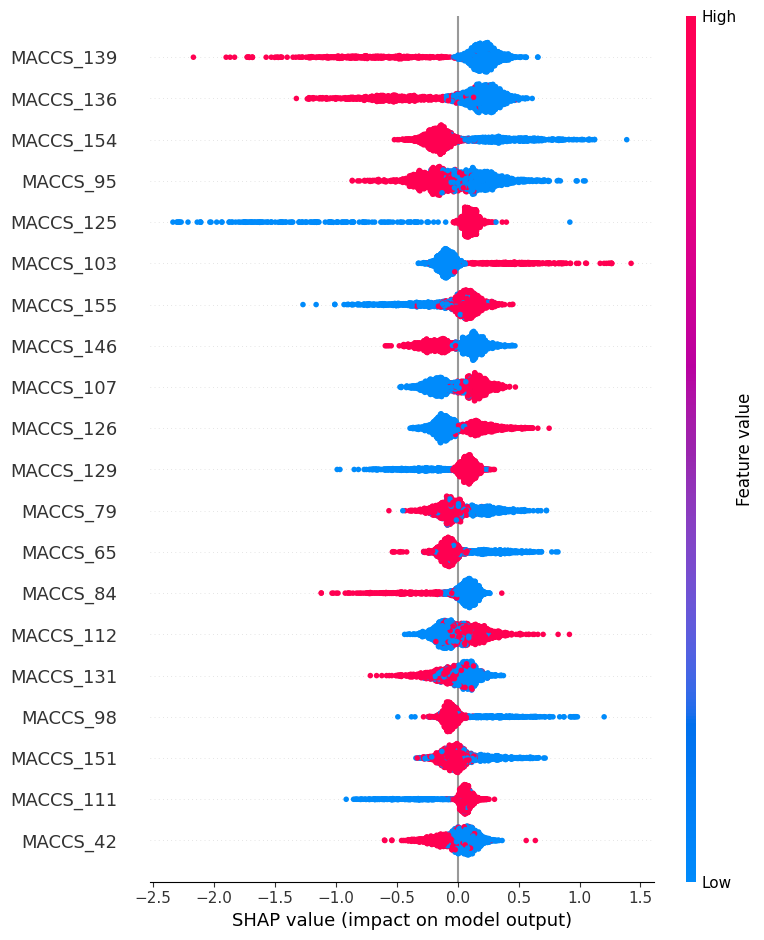

In [30]:
shap.summary_plot(shap_values, X_test)


In [3]:
import pandas
print("Pandas version:", pandas.__version__)


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
numpy	1.26.4
pandas	1.5.3